# 동영상 프레임 추출
- 영상을 이미지 프레임 단위로 쪼개서 시간 정보를 분리하는 실습

- 동영상(Video)의 특징
    - 시간(Time) 축을 따라 연속적으로 배열된 이미지(프레임, Frame) 의 모음
    - 1초 동안 여러 장의 이미지(보통 24~60fps)가 빠르게 바뀌면서 사람의 눈에는 움직이는 장면처럼 보임
    - 즉, 영상 = 이미지(공간 정보) + 시간(변화 정보). 시간을 가진 이미지의 집합.

- 구조적 구성
    - Frame(프레임) : 영상의 한 장면(=정지 이미지)
    - FPS(Frame Per Second) : 초당 몇 장의 이미지가 재생되는가(영상의 부드러움 결정)
    - Resolution(해상도) : 한 프레임의 크기 (예: 1920×1080)
    - Duration(길이) : 전체 영상의 재생 시간 (초 단위)
    - Codec / Container : 영상을 저장·압축하는 포맷 (예: H.264, MP4 등)

## 0.환경 설정

In [2]:
base_path = r'C:\Users\playdata2\work_space(playdata)\SKN30_playdata\AI_agent\multimodal_ai'

In [3]:
%pip install opencv-python tqdm pillow

Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import cv2
from tqdm import tqdm
from PIL import Image
from IPython.display import display

## 1.동영상 요약/미리보기
- 입력 동영상 1개에 대해 첫 프레임을 읽어서 썸네일(최대 thumb_size) 이미지로 표시

In [ ]:
def show_video_summary(
    base_path='.',  # 기본값: 현재 노트북 셀의 작업 디렉터리
    video_dir='video',
    video_file=None,
    thumb_size=(240, 135)   # (width, height): 최대 사이즈
):
    assert video_file is not None, "video_file 인수는 반드시 지정해야 합니다."
    video_path = os.path.join(base_path, video_dir, video_file)
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Can't open: {video_path}")
        return

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    duration = frame_count / fps if fps > 0 else 0

    # 첫 프레임(썸네일) 추출
    ret, frame = cap.read()
    cap.release()
    if not ret:
        print(f"썸네일 추출 실패: {video_path}")
        thumbnail = None
    else:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        thumbnail = Image.fromarray(frame_rgb)
        thumbnail.thumbnail(thumb_size)

    print(f"동영상 파일명: {video_file}")
    print(f"총 프레임 수 : {frame_count}")
    print(f"프레임 레이트: {fps:.2f} FPS")
    print(f"동영상 길이  : {duration:.2f}초")

    if thumbnail:
        display(thumbnail)

## 2.폴더 내 동영상 일괄 미리보기
- 파일 요약 정보 + 썸네일 확인


동영상 파일명: alpinist.mp4
총 프레임 수 : 208
프레임 레이트: 30.00 FPS
동영상 길이  : 6.93초


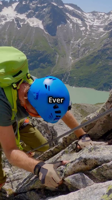

동영상 파일명: basketball.mp4
총 프레임 수 : 172
프레임 레이트: 30.00 FPS
동영상 길이  : 5.73초


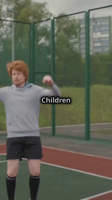

동영상 파일명: female_player_after_scoring.mp4
총 프레임 수 : 210
프레임 레이트: 30.00 FPS
동영상 길이  : 7.00초


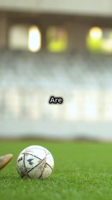

동영상 파일명: jogging.mp4
총 프레임 수 : 166
프레임 레이트: 30.00 FPS
동영상 길이  : 5.53초


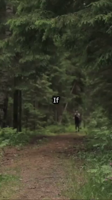

동영상 파일명: skiing.mp4
총 프레임 수 : 58
프레임 레이트: 30.53 FPS
동영상 길이  : 1.90초


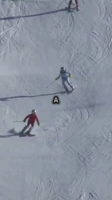

동영상 파일명: soccer_pass.mp4
총 프레임 수 : 124
프레임 레이트: 30.00 FPS
동영상 길이  : 4.13초


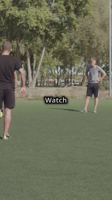

동영상 파일명: soccer_player_head.mp4
총 프레임 수 : 197
프레임 레이트: 30.00 FPS
동영상 길이  : 6.57초


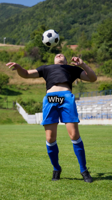

동영상 파일명: surfer.mp4
총 프레임 수 : 195
프레임 레이트: 30.00 FPS
동영상 길이  : 6.50초


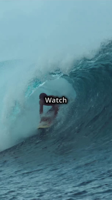

동영상 파일명: swimming.mp4
총 프레임 수 : 254
프레임 레이트: 30.00 FPS
동영상 길이  : 8.47초


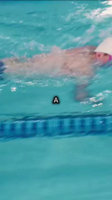

In [8]:
video_dir = 'video'

for video_file in os.listdir(os.path.join(base_path, video_dir)):
    if video_file.endswith('.mp4'):
        show_video_summary(base_path, video_dir, video_file, thumb_size=(300, 200))
        print("="*50)


## 3.프레임 추출

- 프레임 추출 함수

In [9]:
# videos/ 폴더의 .mp4만 순회 -> 파일별 요약 정보 + 썸네일 확인.
# OpenCV로 프레임 순회하며 frame_interval 프레임마다 저장

def extract_frames_from_videos(
    base_path='.',
    video_dir='video',
    frame_dir='frames',
    frame_interval=1      
):
    video_dir_path = os.path.join(base_path, video_dir)
    frame_dir_path = os.path.join(base_path, frame_dir)
    os.makedirs(frame_dir_path, exist_ok=True)
    video_files = [f for f in os.listdir(video_dir_path) if f.endswith('.mp4')]

    for idx_file, video_file in enumerate(video_files):
        video_path = os.path.join(video_dir_path, video_file)
        video_name = os.path.splitext(video_file)[0]
        save_subdir = os.path.join(frame_dir_path, video_name)
        os.makedirs(save_subdir, exist_ok=True)

        cap = cv2.VideoCapture(video_path)
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        idx = 0
        saved_idx = 0

        pbar = tqdm(total=frame_count, desc=f"{video_name}", leave=True, ncols=100)
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            if idx % frame_interval == 0:
                frame_path = os.path.join(save_subdir, f"{video_name}_frame{idx:05d}.jpg")
                cv2.imwrite(frame_path, frame)
                saved_idx += 1
            idx += 1
            pbar.update(1)
        cap.release()
        pbar.close()

        if idx_file == len(video_files) - 1:
            tqdm.write("")
        tqdm.write(f"{video_name}: 총 {frame_count}프레임 중 {saved_idx}개 저장")

    print("모든 동영상 프레임 추출이 완료되었습니다.")


- 프레임 추출 실행

In [10]:
extract_frames_from_videos(
    base_path=base_path,
    video_dir='video',          # 동영상 폴더
    frame_dir='frames',         # 프레임 저장 폴더
    frame_interval=1            # 프레임 간격
)

alpinist: 100%|███████████████████████████████████████████████████| 208/208 [00:04<00:00, 46.09it/s]


alpinist: 총 208프레임 중 208개 저장


basketball: 100%|█████████████████████████████████████████████████| 172/172 [00:02<00:00, 57.40it/s]


basketball: 총 172프레임 중 172개 저장


female_player_after_scoring: 100%|████████████████████████████████| 210/210 [00:03<00:00, 54.99it/s]


...

soccer_player_head: 총 197프레임 중 197개 저장


surfer: 100%|█████████████████████████████████████████████████████| 195/195 [00:03<00:00, 52.52it/s]


surfer: 총 195프레임 중 195개 저장


swimming: 100%|██████████████████████████████████████████████████| 254/254 [00:01<00:00, 201.14it/s]


swimming: 총 254프레임 중 254개 저장
모든 동영상 프레임 추출이 완료되었습니다.
